# =============================================================================
# SEMANA 4: APRENDIZAJE NO SUPERVISADO - SEGMENTACIÓN DE CLIENTES
#
Laura Daniela Grisales Franco

=============================================================================



### Introducción

Este notebook tiene como objetivo realizar una segmentación de clientes utilizando el algoritmo de clustering **K-Means**, una técnica fundamental dentro del aprendizaje no supervisado. El análisis se llevará a cabo sobre un conjunto de datos de clientes de un centro comercial, que incluye variables clave como los ingresos anuales y el puntaje de gasto. El propósito es identificar grupos de clientes con comportamientos y características similares, lo que permitirá al centro comercial diseñar estrategias de marketing y comerciales más personalizadas y efectivas. A lo largo de este análisis, exploraremos los datos, aplicaremos la regla del codo para determinar el número óptimo de clústeres, ejecutaremos el modelo K-Means, visualizaremos los resultados con PCA y, finalmente, interpretaremos los segmentos desde una perspectiva de negocio, estratégica y ética.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

***II.Cargue el conjunto de datos desde la URL validada en el primer bloque de código.***

In [ ]:
# 1. CARGA DE DATOS
# URL validada y estable para el ejercicio.
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
datos = pd.read_csv(url)

***III.Realice una exploración inicial revisando las estadísticas básicas y los nombres de las columnas.***

In [ ]:
# 2. EXPLORACIÓN Y LIMPIEZA BÁSICA
# Mostramos los primeros datos para conocer las columnas.
datos.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Número de filas y columnas:
print(f"El DataFrame tiene {datos.shape[0]} filas y {datos.shape[1]} columnas.")

# Nombres de las columnas:
print("Nombres de las columnas:")
display(datos.columns)

El DataFrame tiene 200 filas y 5 columnas.
Nombres de las columnas:


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
# ESPACIO DE TRABAJO:
# Verifique si hay datos faltantes (nulos) y elimine duplicados si existen.
# Pista: Use datos.isnull().sum()

In [ ]:
# Estadisticas basicas
print("Esatdisticas basicas:")
display(datos.describe())

Esatdisticas basicas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Segmento_Cliente
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.400000
std,57.879185,13.969007,26.264721,25.823522,1.449311
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


In [ ]:
# Obtener un resumen completo de los tipos de datos y valores no nulos:
print("tipos de datos:")
datos.info()

tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


***IV. Analice las variables del conjunto de datos e identifique cuáles son numéricas y cuáles categóricas. A partir de esta revisión, justifique brevemente por qué un modelo de aprendizaje no supervisado como K-Means es apropiado para este conjunto de datos.***

R: Se identifican 4 variables numericas (CustomerID, Age, Annual Income, Spending Score )y 1 variable categorica (Gender)

R: El modelo de aprendizaje no supervisado K-Means es apropiado para este conjunto de datos por varias razones:

1.  **Objetivo de Segmentación:** El problema busca la 'segmentación de clientes', lo cual es una tarea clásica de clustering o agrupamiento, donde K-Means es uno de los algoritmos más utilizados y efectivos.
2.  **Variables Numéricas Clave:** Las variables `Annual Income (k$)` (Ingresos Anuales) y `Spending Score (1-100)` (Puntaje de Gasto) son de naturaleza numérica. K-Means funciona calculando distancias entre los puntos de datos, lo que lo hace ideal para variables cuantitativas como estas.
3.  **Ausencia de Etiquetas:** Al ser un problema de aprendizaje no supervisado, no contamos con una variable objetivo (etiqueta) que indique a qué segmento pertenece cada cliente. K-Means precisamente se encarga de descubrir estas estructuras ocultas en los datos.
4.  **Simplicidad y Eficiencia:** K-Means es relativamente sencillo de implementar e interpretar, y es computacionalmente eficiente para conjuntos de datos de tamaño moderado como este.

Aunque la variable 'Gender' es categórica, las variables numéricas seleccionadas (`Annual Income` y `Spending Score`) son las que definen el espacio principal para la segmentación en este contexto, haciendo a K-Means una herramienta adecuada para identificar grupos de clientes con patrones de ingreso y gasto similares.

***V.Efectúe una limpieza de datos verificando nulos; en este ejercicio, se busca asegurar que la tabla esté lista para el algoritmo.***

In [ ]:
print("Valores nulos por columna:")
display(datos.isnull().sum())

print("Número de filas duplicadas:")
duplicados = datos.duplicated().sum()
display(duplicados)

if duplicados > 0:
    print("Eliminando filas duplicadas...")
    datos.drop_duplicates(inplace=True)
    print("Duplicados eliminados. Nuevo número de filas:")
    display(len(datos))
else:
    print("No se encontraron filas duplicadas.")

Valores nulos por columna:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Número de filas duplicadas:


np.int64(0)

No se encontraron filas duplicadas.


***VI. Implemente el ciclo para calcular la "suma de errores" y grafique la regla del codo para elegir cuántos grupos crear.***

In [ ]:
# 3. SELECCION DE VARIABLES
# Seleccionamos solo las columnas de interes por su nombre (mas sencillo que usar i­ndices).
# IMPORTANTE! AquI­ no hay columna 'y' (target). No estamos prediciendo, estamos agrupando.
X = datos[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
# 4. REGLA DEL CODO (IDENTIFICAR NÚMERO DE CLÚSTERES)
# Creamos una lista para guardar la "suma de errores" (inercia).
suma_errores = []

# El rango (1, 11) significa que probaremos crear desde 1 hasta 10 grupos.
# Esto nos permite ver en qué punto añadir más grupos ya no mejora mucho el modelo.
for i in range(1, 11):
    # Instrucción: Configura y ajusta KMeans para cada valor de 'i'.
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    suma_errores.append(kmeans.inertia_)

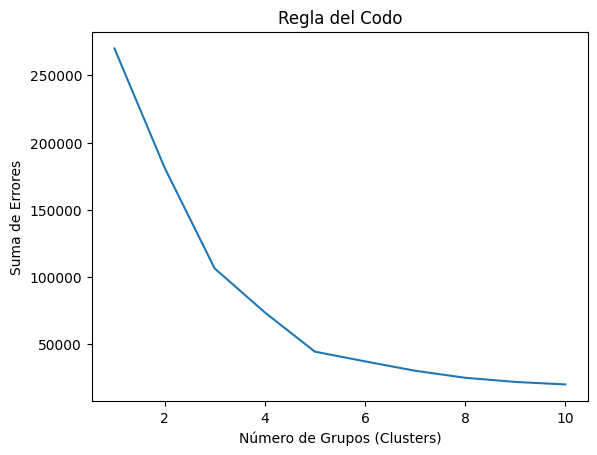

In [ ]:
# Graficamos la suma de errores para buscar el "codo" (punto de inflexiÃ³n).
plt.plot(range(1, 11), suma_errores)
plt.title('Regla del Codo')
plt.xlabel('Número de Grupos (Clusters)')
plt.ylabel('Suma de Errores')
plt.show()

***Nota: En este caso, el 'codo' más evidente se encuentra en los 5 clusters, lo que sugiere que es el número óptimo para segmentar nuestros datos de clientes.***

***VII.Ejecute el modelo K-Means y cree una nueva columna en su tabla original con el número de segmento asignado.***

In [ ]:
# 5. EJECUCIÓN DEL MODELO
# Según el gráfico anterior, defina el número de grupos
num_grupos = 5 # ESPACIO DE TRABAJO: Ingrese el número elegido

In [ ]:
modelo_final = KMeans(n_clusters=num_grupos, init='k-means++', random_state=42)

In [ ]:
# 'asignaciones' guarda el numero de grupo  para cada fila.
asignaciones = modelo_final.fit_predict(X)

In [ ]:
# AGREGAR RESULTADOS AL DATAFRAME ORIGINAL
# Creamos una nueva columna para saber a quÃ© grupo pertenece cada cliente.
datos['Segmento_Cliente'] = asignaciones

***Nota: El modelo K-Means fue ejecutado y la nueva columna (Segmento_Cliente) con el número de segmento asignado***

In [ ]:
datos.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Segmento_Cliente
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


***VIII.Analice la visualización por PCA siguiendo las instrucciones para entender cómo se agrupan los datos en dos dimensiones.***

In [ ]:
# 6. VISUALIZACION CON PCA
# Como tenemos varias variables, PCA las "resume" en 2 Componentes.
# Es como tomar una foto 2D de un objeto 3D: perdemos un poco de detalle,
# pero podemos ver la forma general de los grupos en una grÃ¡fica simple.
pca = PCA(n_components=2)
datos_reducidos = pca.fit_transform(X)

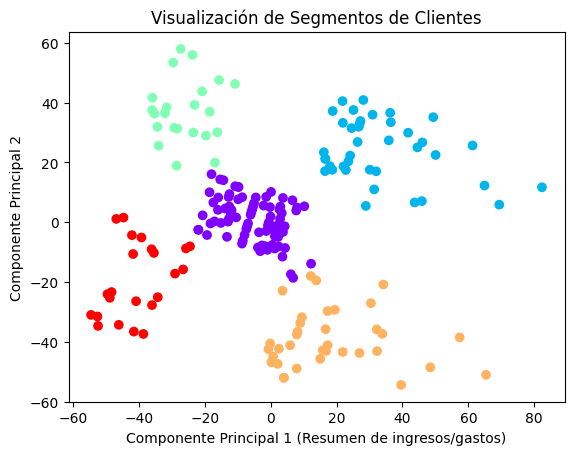

In [ ]:
# plt.scatter dibuja los puntos. 'c' define el color segÃºn el grupo asignado.
plt.scatter(datos_reducidos[:, 0], datos_reducidos[:, 1], c=asignaciones, cmap='rainbow')
plt.title('Visualización de Segmentos de Clientes')
plt.xlabel('Componente Principal 1 (Resumen de ingresos/gastos)')
plt.ylabel('Componente Principal 2')
plt.show()

### Análisis de la Visualización por PCA

La gráfica de dispersión que se ha generado a partir de la reducción de dimensionalidad con PCA (Análisis de Componentes Principales) te permite observar visualmente cómo se distribuyen y agrupan los clientes en un espacio bidimensional. Cada punto en la gráfica representa un cliente, y el color de cada punto indica el segmento de cliente al que fue asignado por el modelo K-Means.

**Cómo interpretar la gráfica:**

*   **Ejes (Componente Principal 1 y Componente Principal 2):** Estos ejes son nuevas variables creadas por PCA que capturan la mayor parte de la variabilidad original de tus datos ('Annual Income (k$)' y 'Spending Score (1-100)'). El Componente Principal 1 generalmente explica la mayor parte de la varianza, y el Componente Principal 2 la segunda mayor. Aunque no tienen un significado directo en términos de 'ingreso' o 'gasto' como las variables originales, representan combinaciones de estas que maximizan la separación de los datos.

*   **Clusters (grupos de colores):** Cada grupo de puntos del mismo color representa un segmento de clientes. La idea es que los clientes dentro de un mismo segmento (mismo color) son más similares entre sí que con los clientes de otros segmentos (otros colores).

*   **Separación de Grupos:** Observa la distancia entre los diferentes grupos de colores. Una buena segmentación K-Means resultará en grupos que están bien separados entre sí, lo que indica que los segmentos son distintos y tienen características de ingresos/gastos diferentes.

*   **Densidad de Grupos:** Dentro de cada grupo, la densidad de los puntos te dice qué tan compactos son los clientes en ese segmento. Los grupos más densos indican que los clientes dentro de ese segmento son muy similares entre sí.

*   **Anomalías/Outliers:** Si ves puntos que están muy alejados de cualquier grupo de color o que parecen estar entre dos grupos, podrían ser clientes atípicos que no encajan claramente en ninguno de los segmentos definidos.

**En resumen, esta visualización te ayuda a confirmar visualmente que el modelo K-Means ha logrado identificar distintos grupos de clientes basados en sus patrones de ingresos y gastos, y te permite ver la 'forma' y la 'separación' de estos segmentos en un formato fácil de entender.**

### Análisis de Segmentos para responder las preguntas

In [ ]:
segmentos_analisis = datos.groupby('Segmento_Cliente')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(segmentos_analisis)

,Annual Income (k$),Spending Score (1-100)
Segmento_Cliente,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


***IX.Analice los resultados obtenidos a partir de los clústeres generados. Reflexione sobre cómo podrían interpretarse estos segmentos en un contexto de negocio, qué decisiones estratégicas podrían derivarse de ellos y qué consideraciones éticas deberían tenerse en cuenta al aplicar este tipo de modelos en la segmentación de clientes.***

In [ ]:
# -----------------------------------------------------------------------------
# RESUELVA COMO LLEVAR LOS MODELOS A LA REALIDAD?
# -----------------------------------------------------------------------------
# Responda las siguientes preguntas basÃ¡ndose en su grÃ¡fica y tabla final:
#
# 1. ANALÃTICA: Identifique el grupo que tiene ingresos bajos pero un puntaje
#    de gasto muy alto. Â¿QuÃ© cree que motiva a este grupo de clientes?
#
# 2. GERENCIAL: Si usted fuera el gerente de este centro comercial, Â¿quÃ© acciÃ³n
#    concreta (promociÃ³n, evento, servicio) propondrÃ­a para el grupo identificado?
#
# 3. Ã‰TICA: Â¿Considera justo que el centro comercial use esta etiqueta para
#    ofrecerle precios distintos a las personas? Â¿Por quÃ©?
#
# Escriba aquÃ­ sus conclusiones finales y resultados obtenidos del ejercicio:

**1. ANALITICA:  Identifique el grupo que tiene ingresos bajos pero un puntaje de gasto muy alto.¿Que cree que motiva a este grupo de clientes?**

El Segmento identificado con Ingresos Bajos y Gasto Alto es (Segmento 2)

**1. Análisis del Segmento:**

*   **Características:** Este grupo se distingue por tener ingresos anuales bajos (aproximadamente $25.7k) pero un puntaje de gasto muy alto (cercano a 79.4). Son clientes que, a pesar de sus limitaciones económicas, demuestran una alta propensión a gastar.

*   **Motivaciones Posibles:**
    *   **Impulsividad:** Podrían ser compradores impulsivos que disfrutan del acto de comprar, buscando gratificación instantánea.
    *   **Cazadores de Ofertas/Valor:** Posiblemente son muy sensibles a las ofertas y promociones, gastando significativamente cuando perciben un gran valor o un 'chollo'.
    *   **Priorización de Gasto:** Aunque sus ingresos son bajos, podrían priorizar ciertas categorías de productos o marcas que son importantes para ellos (ej. moda, tecnología, entretenimiento), recortando en otras áreas.
    *   **Uso de Crédito:** Es posible que dependan de tarjetas de crédito o planes de financiación para realizar sus compras, lo que les permite mantener un alto nivel de gasto a pesar de sus ingresos.
    *   **Necesidad de Estatus:** Podrían buscar productos que les confieran un cierto estatus social, incluso si requieren un esfuerzo económico considerable.

 **2. GERENCIAL: Si usted fuera el gerente de este centro comercial,  que accion concrta propondría
para el grupo identificado?**

Acciones Estratégicas (para un Gerente de Centro Comercial):

*   **Programas de Lealtad con Recompensas:** Implementar un programa donde acumulen puntos o descuentos por cada compra, incentivándolos a seguir gastando y generando un sentido de 'recompensa' por su fidelidad.
*   **Opciones de Financiamiento:** Ofrecer planes de pago a plazos, sin intereses por un período limitado, o facilidades de crédito en colaboración con bancos. Esto les permitiría adquirir productos de mayor valor sin un desembolso inicial grande.
*   **Promociones Dirigidas:** Crear campañas de marketing específicas que enfaticen 'lujo asequible', 'productos de tendencia a buen precio' o 'experiencias exclusivas al mejor valor'.
*   **Eventos y Actividades:** Organizar eventos que no requieran un gasto inicial elevado para participar, pero que creen un ambiente propicio para el gasto, como demostraciones de productos o pequeños talleres con descuentos exclusivos.
*   **Comunicación de Valor:** Destacar el 'valor por el dinero' en la publicidad y las descripciones de productos, mostrando cómo sus compras pueden enriquecer su vida o estatus.

**3.ETICA: ¿Considera justo que el centro comercial use esta etiqueta para ofrecerle precios distintos a las personas? ¿Por que?**

En lugar de ofrecer precios distintos por un mismo producto, el centro comercial debe enfocarse en promociones que añadan valor a este segmento mateniendo la equidad en los precios para evitar la impulsividad o las posibles vulnerabilidades financieras de este grupo. Las promociones y facilidades de crédito deben ser transparentes y responsables, evitando endeudamientos excesivos.


**CONCLUSIONES**

Este ejercicio nos permitió segmentar a los clientes de un centro comercial a partir de dos variables: sus ingresos anuales y su puntaje de gasto. A continuación, las conclusiones más importantes.

**1. Sobre el Método K-Means y la Regla del Codo:**

Este algoritmo demostró ser una herramienta muy efectiva para encontrar grupos que existen de forma natural en los datos, sin necesidad de contar con etiquetas previas, lo que lo hace ideal para tareas de segmentación y descubrimiento de patrones. Para saber cuántos clústeres formar, fue clave aplicar la regla del codo, que en este caso nos llevó a determinar que 5 era el número óptimo. Esta técnica ayuda justamente a encontrar ese punto de equilibrio en el que agregar más grupos ya no reduce de forma importante la variabilidad dentro de cada clúster, evitando así caer en una sobre-segmentación innecesaria. Además, usamos PCA para reducir la dimensionalidad y poder visualizar los clústeres en un espacio de dos dimensiones, lo que nos dio una forma mucho más intuitiva de observar qué tan separados y cohesionados estaban los segmentos, aunque el modelo en realidad se entrenó directamente con las dos características originales.

**2. Sobre los Segmentos de Clientes y sus Implicaciones de Negocio:**

Con este análisis logramos identificar 5 segmentos de clientes, cada uno con un comportamiento de compra distinto. El primero agrupa a clientes con ingresos altos y gasto alto, que representan un alto valor para el negocio y están dispuestos a pagar por exclusividad y calidad, por lo que conviene ofrecerles experiencias VIP y productos premium. El segundo, que resultó ser uno de los hallazgos más interesantes, reúne a clientes con ingresos bajos pero gasto alto: son compradores impulsivos o que buscan sentir que están obteniendo un buen valor, y para ellos funcionan bien las promociones inteligentes, la financiación y los productos de "lujo asequible", acompañados de una comunicación que resalte el valor de lo que compran. El tercero agrupa a clientes con ingresos altos pero gasto bajo, más cautelosos, que probablemente prioricen otras formas de inversión o gasten en otras categorías; a ellos les conviene una comunicación centrada en la calidad y la durabilidad a largo plazo. El cuarto reúne a quienes tienen ingresos bajos y gasto bajo, clientes sensibles al precio con presupuesto limitado, para quienes lo más efectivo son las ofertas masivas, productos económicos y mensajes centrados en el ahorro. Y por último, el segmento con ingresos y gasto medios representa al "cliente promedio", que responde bien a promociones generales.

Poder distinguir estos grupos le da al centro comercial la posibilidad de diseñar estrategias de marketing y ventas mucho más personalizadas, optimizando sus recursos y mejorando la experiencia de cada tipo de cliente.



**3. Consideraciones Éticas en la Segmentación:**

Finalmente, este ejercicio también deja algunas reflexiones éticas importantes sobre la segmentación. Por un lado, no es ético ofrecer precios distintos para un mismo producto según el segmento al que pertenece cada cliente, ya que esto puede derivar en discriminación y generar desconfianza o rechazo. Por otro lado, la segmentación sí puede y debe usarse para personalizar ofertas, promociones, comunicación y servicios de forma relevante para cada grupo, pero nunca para explotar vulnerabilidades ni crear barreras artificiales entre clientes. La clave está en aportar valor de manera transparente y responsable, garantizando que todos los clientes tengan acceso a los mismos precios base.

En definitiva, este análisis le da al centro comercial una base sólida para tomar decisiones estratégicas informadas, dirigir sus esfuerzos de manera más eficiente y, sobre todo, hacerlo de una forma ética que beneficie tanto a la empresa como a sus clientes.